# Beyond one number per material

The screening tutorial produced scalars: an energy, a distance above the hull, a
pass/fail. Plenty of results are not scalars. A diffraction pattern is a curve.
A force is one vector per atom, and the number of atoms differs from material to
material. A measurement is a number somebody took off an instrument rather than
out of a calculator.

This tutorial covers where each of those lives, and why.

In [1]:
import matverse as mv
import numpy as np
import pandas as pd

mv.pl.set_style()

🔬 Starting plot initialization...


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


🧪 Calculators available: 12
    • emt — EMT (LGPL-2.1)
    • lj — Lennard-Jones (LGPL-2.1)
    • mace-mpa — MACE-MPA-0 (MIT)
    • mace-omat — MACE-OMAT-0 (ASL)
    • sevennet — SevenNet (GPL-3.0)
    • chgnet — CHGNet (BSD-3-Clause)
    • m3gnet — M3GNet-PES-MatPES-PBE-2025.2 (BSD-3-Clause)
    • m3gnet-r2scan — M3GNet-PES-MatPES-r2SCAN-2025.2 (BSD-3-Clause)
    • tensornet — TensorNet-PES-MatPES-PBE-2025.2 (BSD-3-Clause)
    • orb — ORB v3 conservative (Apache-2.0)
    • gpaw-pbe — GPAW PBE, PW(500 eV) (GPL-3.0)
    • gpaw-pbe-fast — GPAW PBE, PW(400 eV) (GPL-3.0)
🖥️ NVIDIA CUDA GPUs: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3 — 79.1 GB, compute 9.0

                   __
   ____ ___  ____ _/ /__   _____  _____________
  / __ `__ \/ __ `/ __/ | / / _ \/ ___/ ___/ _ \
 / / / / / / /_/ / /_ | |/ /  __/ /  (__  )  __/
/_/ /_/ /_/\__,_/\__/ |___/\___/_/  /____/\___/

🔖 Version: 0.1.71   🧮 Functions: 218   📚 Tutorials: https://matverse.readthedocs.io/
✅ set_style complete.



## Loading a dataset

The same Al–Ni–Cu library as [Screening, end to end](screening.ipynb): three
elemental fcc metals at their published lattice parameters, four hypothetical
intermetallics.

In [2]:
from pymatgen.core import Lattice, Structure


def l12(host, guest, a):
    return Structure(Lattice.cubic(a), [guest, host, host, host],
                     [[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0]])


elemental = mv.datasets.metals(["Al", "Cu", "Ni"])
md = mv.data.from_structures(mv.structures(elemental) + [
    l12("Al", "Cu", 3.90), l12("Cu", "Al", 3.70), l12("Al", "Ni", 3.78),
    Structure(Lattice.cubic(2.89), ["Al", "Ni"], [[0, 0, 0], [.5, .5, .5]]),
])
mv.pp.describe(md)

md.obs[["formula", "nsites", "density"]].round(3)

,formula,nsites,density
0,Al,4,2.699
1,Cu,4,8.935
2,Ni,4,8.908
3,Al3Cu,4,4.045
4,AlCu3,4,7.134
5,Al3Ni,4,4.293
6,AlNi,2,5.894


## Curves live in `obsm` on a shared grid

pymatgen returns a peak list, and peak lists cannot be compared across materials
because no two share the same peak positions. Broadening each reflection onto a
common grid is what turns a set of patterns into a matrix — and a matrix is
something you can take a distance on, cluster, or subtract a measurement from.

In [3]:
mv.prop.xrd(md, two_theta=(10, 90), step=0.02, fwhm=0.1)

md.obsm["xrd_calc"].shape, mv.grid_of(md, "xrd").shape

((7, 4001), (4001,))

The block is named `'<quantity>_<level>'`, exactly like a scalar:

```
obs['energy_pbe']        a number per material, level in the suffix
obsm['xrd_pbe']          a curve per material, level in the suffix
obsm['xrd_experiment']   the same curve, measured
```

```{note}
This is one convention, not two. An earlier draft of the design had curves using
an AnnData `layer` for the level of theory while scalars used a name suffix, and
listed the split as a wart. Putting curves in `obsm` removed it — and removed
the need for MuData along with it, since a `materials × grid` matrix is aligned
to the material axis and that is what `obsm` is for.
```

The grid itself is stored once, in `uns`, because it is the one thing here that
is **not** aligned to the material axis:

In [4]:
md.uns["grids"]["xrd"]

{'values': array([10.  , 10.02, 10.04, ..., 89.96, 89.98, 90.  ], shape=(4001,)),
 'unit': 'degrees 2theta',
 'wavelength': 'CuKa',
 'fwhm': 0.1,
 'normalized': True}

Text(0.5, 1.0, 'Al, Al₃Cu, AlCu₃ — ordering adds superlattice reflections')

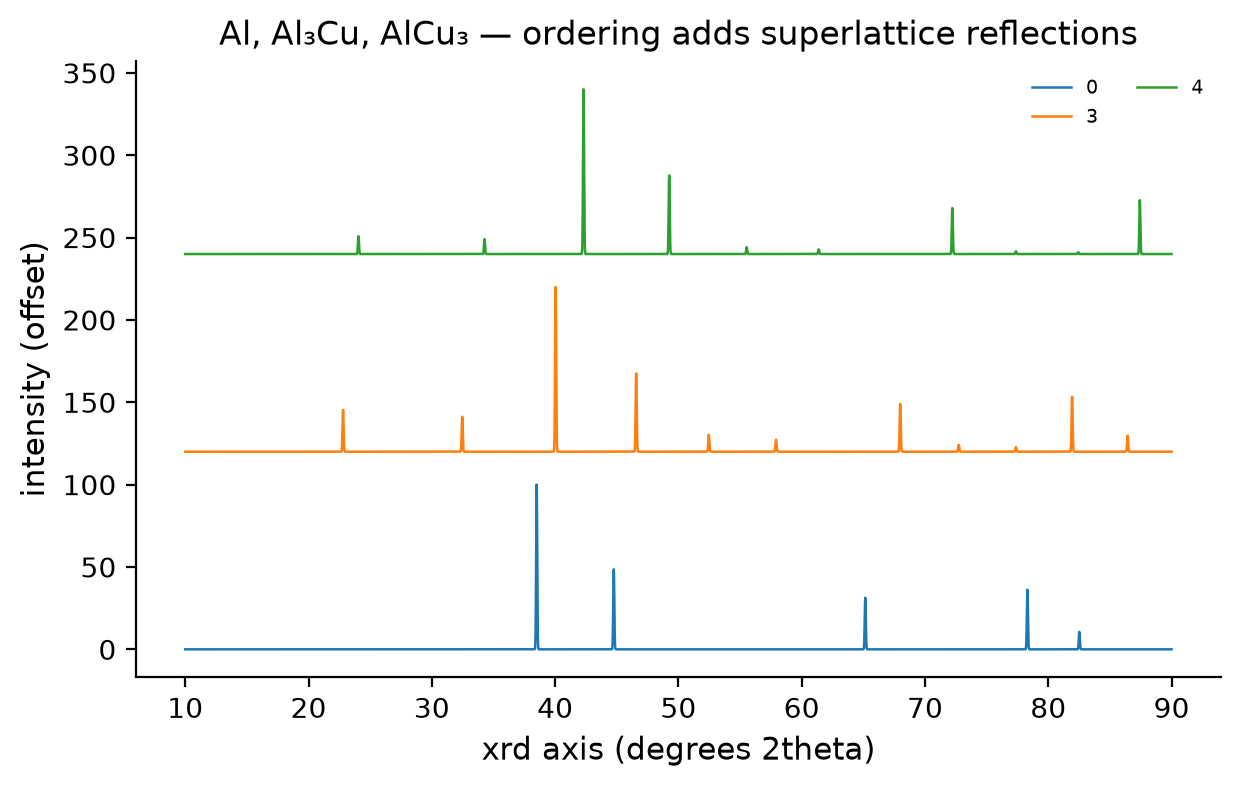

In [5]:
ax = mv.pl.spectra(md, "xrd", rows=[0, 3, 4], offset=120)
ax.set_title("Al, Al₃Cu, AlCu₃ — ordering adds superlattice reflections")

`mv.prop.rdf` is the other curve that ships, and it earns its place by doing
something composition cannot.

Text(0.5, 1.0, 'fcc Al against B2 AlNi')

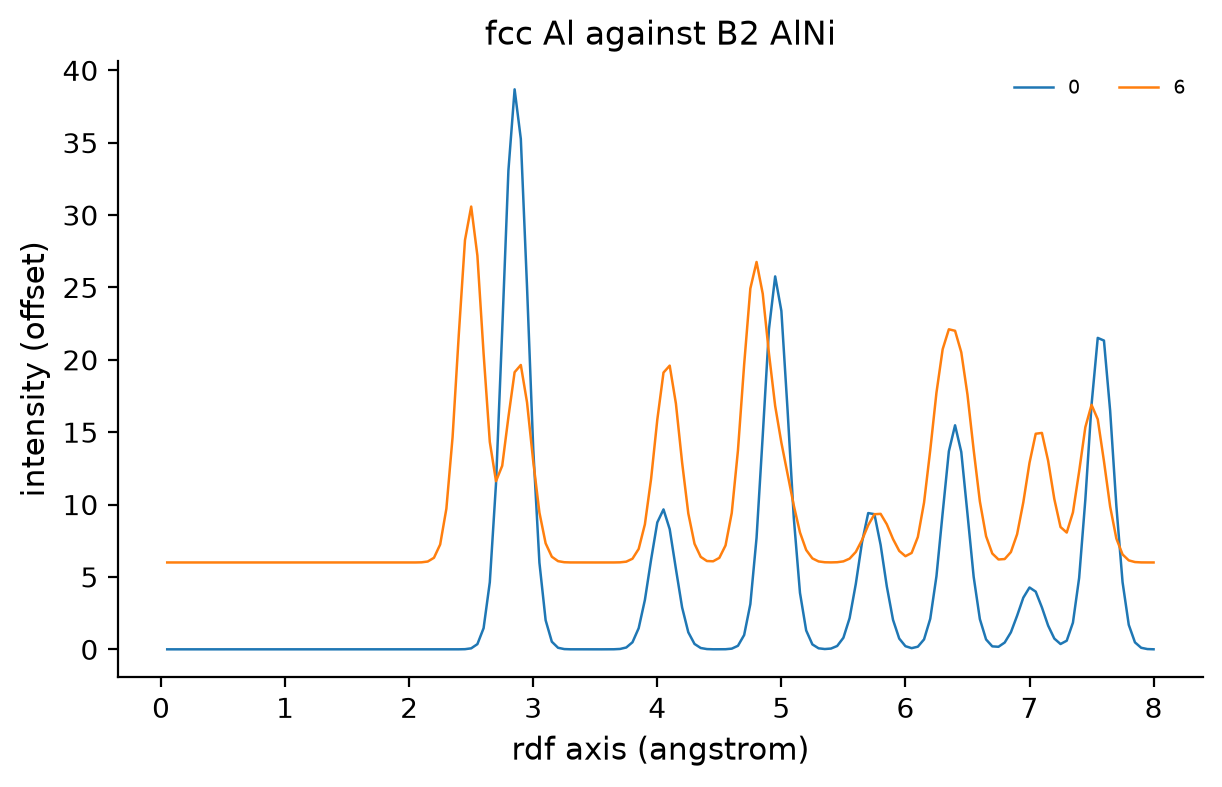

In [6]:
mv.prop.rdf(md, r_max=8.0)

ax = mv.pl.spectra(md, "rdf", rows=[0, 6], offset=6)
ax.set_title("fcc Al against B2 AlNi")

Two polymorphs have the same composition, so `X` cannot tell them apart and
neither can any composition descriptor. A radial distribution function can, and
unlike SOAP it needs no extra dependency.

## Per-atom results get their own axis

Forces are ragged. This library has 4, 4, 4, 4, 4, 4 and 2 atoms — 26 force
vectors, and no way to put them in a column of a seven-row table.

First, something to compute forces *on*. Every structure above is a perfect
cubic cell, and by symmetry the force on every atom in one is exactly zero — a
force example needs displaced atoms. `mv.pp.rattle` is how you make them, and
it is also how force-training sets for machine-learned potentials are built.

In [7]:
mv.pp.rattle(md, stdev=0.05, seed=0)
mv.variants(md)

['input', 'rattled']

In [8]:
sites = mv.multi.sites(md, source="rattled")
sites

AnnData object with n_obs × n_vars = 26 × 3
    obs: 'material', 'material_index', 'site_index', 'element'
    var: 'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
    uns: 'matverse_axis', 'parent', 'provenance'
    obsm: 'X_frac', 'X_cart'
    layers: None (.X)

In [9]:
sites.obs.head(8)

,material,material_index,site_index,element
0:0,0,0,0,Al
0:1,0,0,1,Al
0:2,0,0,2,Al
0:3,0,0,3,Al
1:0,1,1,0,Cu
1:1,1,1,1,Cu
1:2,1,1,2,Cu
1:3,1,1,3,Cu


One row per atom, with `obs['material']` pointing back at the parent. Per-atom
results are a matrix again.

In [10]:
mv.calc.forces(md, sites, level="emt", source="rattled")

sites.obsm["forces_emt"].shape

(26, 3)

In [11]:
sites.obs[["material", "element", "force_magnitude_emt"]].head(8).round(4)

,material,element,force_magnitude_emt
0:0,0,Al,0.1670
0:1,0,Al,0.1702
0:2,0,Al,0.3627
0:3,0,Al,0.2850
1:0,1,Cu,1.3463
1:1,1,Cu,0.7755
1:2,1,Cu,1.0314
1:3,1,Cu,1.2424


Text(0.5, 1.0, 'one point per atom, 26 in total')

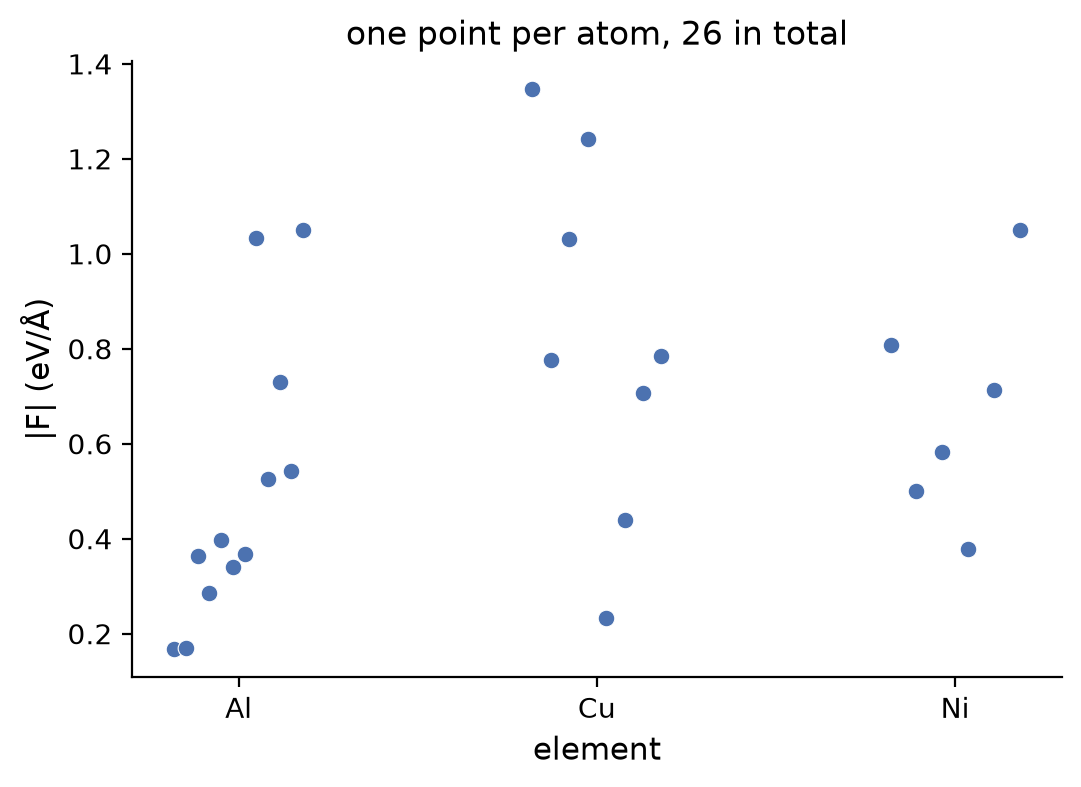

In [12]:
import matplotlib.pyplot as plt      # later cells compose their own figures

ax = mv.pl.scatter(sites, "element", "force_magnitude_emt")
ax.set_ylabel("|F| (eV/Å)")
ax.set_title("one point per atom, 26 in total")

One point per atom says which atoms are unrelaxed. The other question is what
the spread looks like across the whole set, and a mean cannot answer it —
twenty-six atoms averaging 0.05 eV/Å can be twenty-six relaxed atoms, or
twenty-four relaxed atoms and two that are nowhere near:

Text(0.5, 1.0, 'the same numbers, as a distribution')

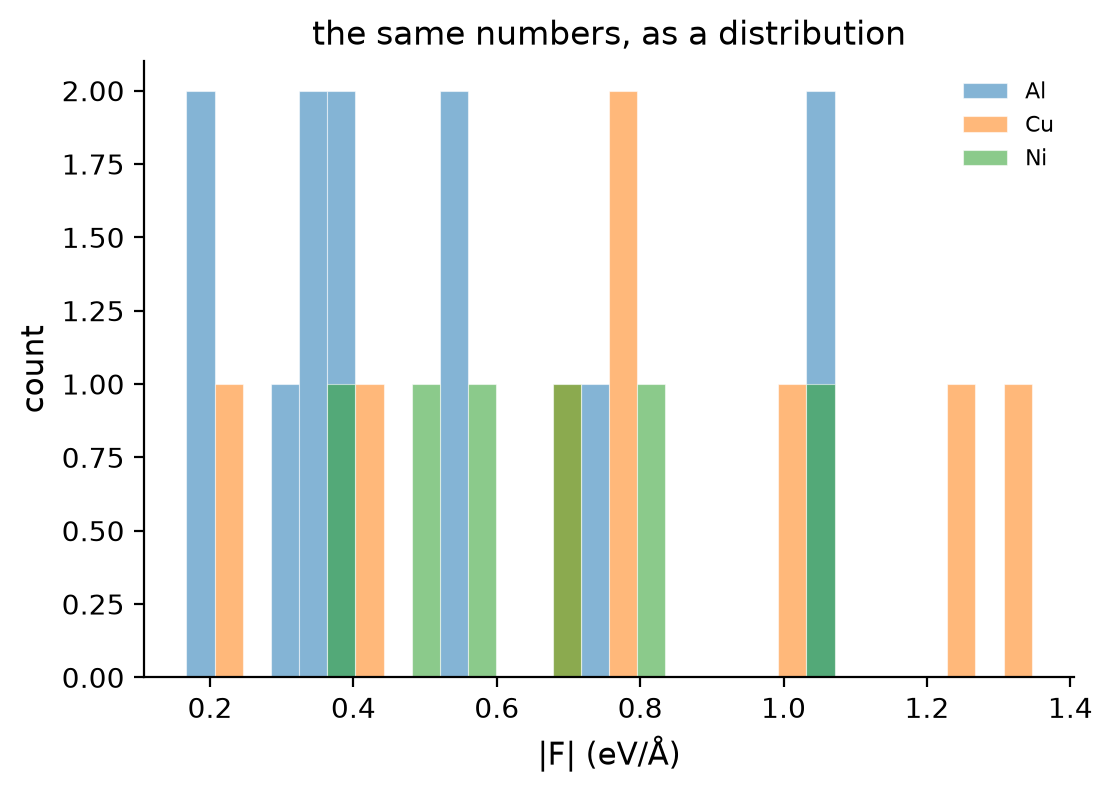

In [13]:
ax = mv.pl.distribution(sites, "force_magnitude_emt", by="element")
ax.set_xlabel("|F| (eV/Å)")
ax.set_title("the same numbers, as a distribution")

Shared bins across the elements, which is the only way the two are being
compared rather than merely drawn beside each other. Non-finite values are
dropped and the count goes in the axis label, so a column that is half missing
cannot pass as a narrow distribution.

Twenty-six points where the material axis has room for seven — which is the
whole reason the sites axis exists.

`mv.calc.forces` takes **both** objects, and the signature is honest about why:
forces need the structures, which live on the material axis, and produce one row
per atom, which lives on the sites axis.

```{warning}
The sites object is a snapshot of one structure variant. If you build it from
`'input'` and then ask for forces on `'relaxed_emt'`, the atoms will not line up
— so matverse refuses rather than silently misaligning them. Rebuild with
`mv.multi.sites(md, source='relaxed_emt')`.
```

### Getting back to the material axis

A per-site result is not screenable until it is summarised.

In [14]:
mv.multi.aggregate(sites, md, "force_magnitude_emt", how="max")

md.obs[["formula", "force_magnitude_emt_max"]].round(4)

,formula,force_magnitude_emt_max
0,Al,0.3627
1,Cu,1.3463
2,Ni,0.8071
3,Al3Cu,0.3973
4,AlCu3,1.0337
5,Al3Ni,0.7290
6,AlNi,1.0499


The largest force in each cell, on the material axis, where a screen can reach
it. A residual force is a useful convergence criterion: the cells that respond
least to being rattled are the ones sitting in the stiffest local minimum.

In [15]:
mv.screen.filter(md, force_magnitude_emt_max__lt=0.8, name="soft_response")
md.obs[["formula", "force_magnitude_emt_max", "soft_response"]].round(4)

,formula,force_magnitude_emt_max,soft_response
0,Al,0.3627,True
1,Cu,1.3463,False
2,Ni,0.8071,False
3,Al3Cu,0.3973,True
4,AlCu3,1.0337,False
5,Al3Ni,0.7290,True
6,AlNi,1.0499,False


The detail stays on the sites object where it can still be inspected; the
summary lands on the materials object where a screen can reach it.

### The element axis is shared

`sites.X` is the one-hot element indicator, so `sites.var` is the same periodic
table the parent carries. Everything written for element-level questions works
on atoms without modification.

In [16]:
forces = sites.obs["force_magnitude_emt"].to_numpy(dtype=float)
sites.obs["strained"] = forces > np.median(forces)
mv.tl.rank_elements_groups(sites, "strained")

sites.uns["rank_elements_groups"]["True"][
    ["element", "n_in_group", "frac_in_group", "odds_ratio", "pval"]]

,element,n_in_group,frac_in_group,odds_ratio,pval
0,Al,3,0.230769,0.133333,0.047180
1,Cu,6,0.461538,4.714286,0.201556
2,Ni,4,0.307692,2.444444,0.644720


That is `rank_genes_groups` answering "which elements sit in the highest-force
environments", and it needed no new function.

### One object, if you want one

In [17]:
try:
    mdata = mv.multi.to_mudata(md, sites)
    result = mdata
except ImportError as exc:
    result = str(exc)[:160]        # needs matverse[multi]
result

MuData object with n_obs × n_vars = 33 × 6
  2 modalities
    materials:	7 × 3
      obs:	'formula', 'nsites', 'n_elements', 'molecular_weight', 'volume', 'density', 'volume_per_atom', 'is_periodic', 'force_magnitude_emt_max', 'soft_response'
      var:	'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
      uns:	'features', 'levels', 'provenance', 'X_is', 'grids', 'screens'
      obsm:	'structures', 'xrd_calc', 'rdf_calc'
      layers:	None
    sites:	26 × 3
      obs:	'material', 'material_index', 'site_index', 'element', 'force_magnitude_emt', 'strained'
      var:	'Z', 'atomic_mass', 'atomic_radius', 'electronegativity', 'group', 'period', 'melting_point', 'boiling_point', 'molar_volume', 'thermal_conductivity', 'electrical_resistivity', 'average_ionic_radius', 'max_oxidation_state', 'min_oxidation_state', 'is_metal', 'is_transition_metal', 'is_alkali', 'is_alkaline', 'is_metalloid', 'is_halogen', 'is_noble_gas', 'is_chalcogen', 'is_lanthanoid', 'is_actinoid', 'is_rare_earth_metal', 'block'
      uns:	'matverse_axis', 'parent', 'provenance', 'levels', 'rank_elements_groups'
      obsm:	'X_frac', 'X_cart', 'forces_emt'
      layers:	None

Optional throughout. matverse's operations take `AnnData`, and the sites object
is useful without ever being assembled — the MuData is for when you want the
two axes travelling as one file.

In [18]:
mv.prop.tem(md, r_max=1.2, step=0.02)
md.obs[["formula", "tem_n_reflections_calc", "tem_strongest_calc",
        "tem_zone_axis"]]

,formula,tem_n_reflections_calc,tem_strongest_calc,tem_zone_axis
0,Al,120.0,"(0, -2, 0)","0,0,1"
1,Cu,120.0,"(0, -2, 0)","0,0,1"
2,Ni,120.0,"(0, -2, 0)","0,0,1"
3,Al3Cu,483.0,"(0, -2, 0)","0,0,1"
4,AlCu3,483.0,"(0, -2, 0)","0,0,1"
5,Al3Ni,483.0,"(0, -2, 0)","0,0,1"
6,AlNi,483.0,"(-1, -1, 0)","0,0,1"


A TEM pattern is spots on a plane, and a plane of spots does not compare across
materials — two crystals on the same zone axis put different spots in different
places. What goes into `obsm` is the **ring profile**: intensity against the
magnitude of the scattering vector, which is what a polycrystalline
selected-area pattern looks like and what can share an axis with an X-ray or
neutron pattern.

`obs` keeps the two facts the reduction loses — how many reflections were
excited, and the strongest one's Miller indices — and the **zone axis**, without
which the pattern means nothing.

```{note}
Those columns show the F-centring rule rather than assert it. A face-centred
lattice allows only all-even or all-odd `hkl`, one reflection in four, so an fcc
metal keeps a quarter of what a simple cubic cell does — and (010), extinct in
fcc, is the brightest spot in simple cubic.
```

## A result computed somewhere else

Everything so far, matverse computed. Plenty of the results a screen wants it
cannot compute at all: a chemical shielding tensor, a piezoelectric tensor and
a dielectric function all come out of a DFT code, and no cheap potential
produces any of them.

That is not a reason for the object to have nothing to say about them. The step
*after* the calculation — reduce a tensor to the parameters a spectrum is
described by, check it against the crystal symmetry, turn a dielectric function
into an efficiency — is arithmetic with conventions in it, and conventions are
exactly what gets a result quoted wrongly.

So these functions take the computed quantity as an **argument**, the same way
`mv.elec.bands` takes band structures and `mv.exp.attach` takes measured curves.

### A tensor per atom

NMR shielding is per-atom, so it lands on the sites axis. Here is a tensor with
principal values 10, 20 and 60 — round numbers, so every convention has a hand
answer.

In [19]:
shieldings = np.tile(np.diag([10.0, 20.0, 60.0]), (sites.n_obs, 1, 1))
mv.prop.nmr(md, sites, shieldings, level="pbe")

sites.obs[["material", "element", "shielding_iso_pbe",
           "shielding_anisotropy_pbe", "shielding_asymmetry_pbe",
           "shielding_span_pbe", "shielding_skew_pbe"]].head(4).round(3)

,material,element,shielding_iso_pbe,shielding_anisotropy_pbe,shielding_asymmetry_pbe,shielding_span_pbe,shielding_skew_pbe
0:0,0,Al,30.0,30.0,0.333,50.0,-0.6
0:1,0,Al,30.0,30.0,0.333,50.0,-0.6
0:2,0,Al,30.0,30.0,0.333,50.0,-0.6
0:3,0,Al,30.0,30.0,0.333,50.0,-0.6


`sigma_iso` is 30, the trace over three. `zeta` is 30, which is
`sigma_33 - sigma_iso`. `eta` is 1/3, the span is 50 and the skew −0.6.

Two conventions are reported because both are in use and **they disagree about
what "anisotropy" means**: Haeberlen's `zeta` is `sigma_33 - sigma_iso`, while
the reduced anisotropy most spectrometer software prints is 3/2 of it. Span and
skew are the Herzfeld-Berger pair a sideband analysis returns. A single column
called `anisotropy` would be wrong for half its readers.

These are **shieldings**, not shifts — a shift is a shielding referenced to a
standard compound, and it runs the other way in sign.

The electric field gradient is the other half of a solid-state NMR experiment,
and it sets the lineshape of every quadrupolar nucleus.

In [20]:
gradients = np.tile(np.diag([-1.0, -2.0, 3.0]), (sites.n_obs, 1, 1))
mv.prop.efg(md, sites, gradients, level="pbe")

sites.obs[["element", "efg_vzz_pbe", "efg_asymmetry_pbe",
           "efg_coupling_pbe"]].head(4).round(3)

/scratch/users/steorra/env/mv312/lib/python3.12/site-packages/pymatgen/core/units.py:327: ComplexWarning: Casting complex values to real discards the imaginary part
  new = float.__new__(cls, val)


,element,efg_vzz_pbe,efg_asymmetry_pbe,efg_coupling_pbe
0:0,Al,3.0,0.333,-1.063
0:1,Al,3.0,0.333,-1.063
0:2,Al,3.0,0.333,-1.063
0:3,Al,3.0,0.333,-1.063


The coupling constant is the only one of the three that needs to know which
*nucleus* it is looking at — a quadrupole moment is a property of the isotope,
not of the calculation — so it is looked up from the element on the site.

### A tensor per material, checked against symmetry

α-quartz is the piezoelectric everyone learns first. Its measured constants are
d₁₁ = 2.3 pC/N and d₁₄ = −0.67 pC/N, and its point group 32 fixes the rest of
the matrix.

In [21]:
from pymatgen.core import Lattice, Structure

quartz = mv.data.from_structures([Structure.from_spacegroup(
    "P3121", Lattice.hexagonal(4.913, 5.405), ["Si", "O"],
    [[0.4697, 0.0, 0.0], [0.4135, 0.2669, 0.1191]])])
mv.pp.describe(quartz)

d11, d14 = 2.3, -0.67
voigt = np.array([[[d11, -d11, 0, d14, 0, 0],
                   [0, 0, 0, 0, -d14, -2 * d11],
                   [0, 0, 0, 0, 0, 0]]])

mv.prop.piezoelectric(quartz, voigt, level="exp")
quartz.obs[["formula", "piezo_max_longitudinal_exp",
            "piezo_symmetry_valid_exp"]].round(3)

,formula,piezo_max_longitudinal_exp,piezo_symmetry_valid_exp
0,SiO,2.297,True


**2.30 pC/N**, recovered from the tensor without being told where to look. For
class 32 the longitudinal response in the basal plane goes as `d11 cos(3θ)`, so
its maximum over all directions *is* d₁₁ — which is why the maximum is the
screening number rather than any single component. Components depend on how
somebody oriented the cell; the maximum does not.

`piezo_symmetry_valid` is the column to read first. Put the same tensor on a
centrosymmetric crystal and it fails, because inversion symmetry forbids
piezoelectricity outright:

In [22]:
copper = mv.datasets.metals(["Cu"])
mv.pp.describe(copper)
mv.prop.piezoelectric(copper, voigt, level="bogus")

bool(copper.obs["piezo_symmetry_valid_bogus"].iloc[0])

False

`False` — and a non-zero piezoelectric tensor on an fcc metal is an error in the
calculation, or a tensor paired with the wrong structure, rather than a
discovery.

### A spectrum per material, and what it is worth

A dielectric function is a curve, so it goes where curves go. The absorption
coefficient is **derived** from it rather than stored alongside it, because
`α = 2Ek/ħc` is a definition and a spectrum that has been through it twice
cannot be reconstructed.

In [23]:
energies = np.linspace(0.3, 4.0, 800)
gaps = [1.34, 0.90, 2.50, 1.34, 1.34, 1.34, 1.34]

# A model absorber: a step edge at the gap. The last four share a gap and
# differ only in how strongly they absorb above it.
strength = [6.0, 6.0, 6.0, 6.0, 0.5, 0.05, 0.005]
eps1 = np.tile(4.0, (md.n_obs, energies.size))
eps2 = np.stack([np.where(energies >= g, s, 0.0)
                 for g, s in zip(gaps, strength)])

mv.prop.dielectric(md, energies, eps1, eps2, level="pbe")
md.obs["band_gap_pbe"] = gaps
md.obsm["absorption_pbe"].shape

(7, 800)

In [24]:
mv.prop.slme(md, level="pbe", thickness=5e-7)

md.obs[["band_gap_pbe", "slme_pbe", "sq_limit_pbe"]].round(2)

,band_gap_pbe,slme_pbe,sq_limit_pbe
0,1.34,33.94,33.94
1,0.90,29.81,29.81
2,2.50,12.59,12.59
3,1.34,33.94,33.94
4,1.34,30.79,33.94
5,1.34,7.61,33.94
6,1.34,0.86,33.94


Read the first three rows against the last four.

Rows 0–2 differ only in **gap**, and `sq_limit` traces the Shockley-Queisser
curve: 1.34 eV beats both 0.90 and 2.50, which is why 1.34 eV is quoted as the
optimum for a single junction. Row 0 lands near 33%, the textbook limit — a
model absorber with a step edge and no indirect gap *is* the Shockley-Queisser
idealisation, so reproducing it is the calibration rather than a result.

Rows 3–6 all have the **same gap** and therefore the same `sq_limit`, and
wildly different `slme`. That spread is the whole reason this function exists.
A screen ranked on band gap cannot tell those four apart — by that measure they
are one candidate. They are not one candidate.

```{note}
`slme` is a **percentage**, and the unit is recorded rather than left to the
reader; `mv.utils.check_units(md)` will say so. pymatgen's own `slme()` returns
the same number with no unit in its docstring, which is precisely the kind of
thing that becomes a factor of 100 three functions downstream.
```

An indirect gap costs efficiency on top of that, through the radiative fraction
`exp(-(E_direct - E_indirect)/kT)`. Left unset, the direct gap is used for both,
which is the optimistic Shockley-Queisser assumption:

In [25]:
md.obs["gap_indirect_pbe"] = [g - 0.3 for g in gaps]
mv.prop.slme(md, level="pbe", thickness=5e-7,
             indirect_key="gap_indirect_pbe")

md.obs[["band_gap_pbe", "gap_indirect_pbe", "slme_pbe"]].head(3).round(2)

,band_gap_pbe,gap_indirect_pbe,slme_pbe
0,1.34,1.04,23.75
1,0.90,0.60,15.04
2,2.50,2.20,10.76


That is the penalty silicon pays, and the reason a direct-gap absorber a tenth
as thick can outperform it.

## Experiment is a level of theory

This needed no new machinery, which is the argument for having typed the level
of theory in the first place. Two calculated levels and one measured one, on the
same quantity:

In [26]:
mv.calc.energy(md, level="emt")
md.obs["energy_per_atom_shifted"] = \
    md.obs["energy_per_atom_emt"].to_numpy(dtype=float) - 0.05
mv.set_level(md, "shifted", kind="classical", method="EMT with an offset")

measured = md.obs["energy_per_atom_emt"].to_numpy(dtype=float) + 0.02
mv.exp.measure(md, "energy_per_atom", measured, instrument="calorimeter")

mv.compare_levels(md, "energy_per_atom").round(4)

,emt,experiment,shifted
0,-0.0016,0.0184,-0.0516
1,-0.0050,0.0150,-0.0550
2,-0.0076,0.0124,-0.0576
3,0.0796,0.0996,0.0296
4,0.1093,0.1293,0.0593
5,0.1829,0.2029,0.1329
6,0.4306,0.4506,0.3806


Three numbers, three levels, one table, and nobody had to decide which one is
"the" energy. `uns['levels']['experiment']` records the instrument where
`uns['levels']['emt']` records the method:

In [27]:
mv.level_info(md, "experiment")

{'kind': 'experiment',
 'method': 'calorimeter',
 'reference': None,
 'surrogate': False,
 'license': None,
 'uncertainty': None,
 'instrument': 'calorimeter'}

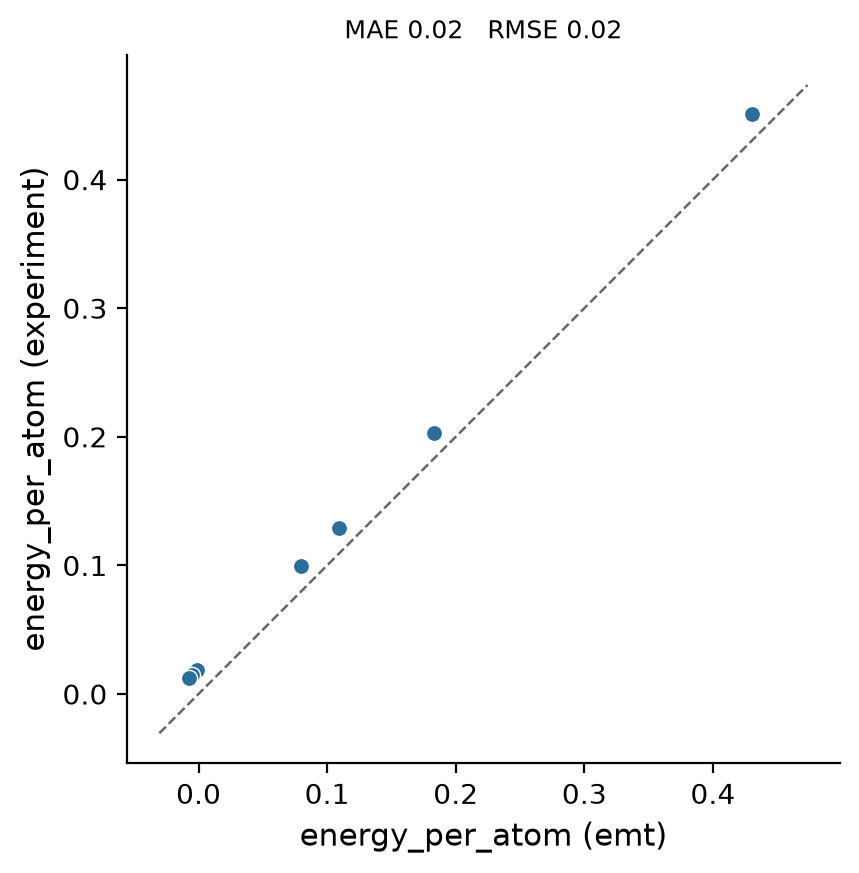

In [28]:
ax = mv.pl.parity(md, "energy_per_atom", "emt", "experiment")

`mv.pl.parity` annotates the error and — the useful bit — prints a warning on
the plot when the two levels reproduce different methods. A parity plot silently
comparing PBE against r2SCAN looks exactly like one comparing PBE against PBE.

### Phase identification

The compelling case is a measured pattern against a candidate library. Take the
Al₃Cu pattern, add noise and a sloping background, and hand it back as though it
came off an instrument.

In [29]:
rng = np.random.default_rng(0)
two_theta = mv.grid_of(md, "xrd")
observed = (md.obsm["xrd_calc"][3]
            + rng.normal(0, 0.5, two_theta.size)      # counting noise
            + 0.02 * two_theta)                        # sloping background

mv.exp.match_xrd(md, observed, two_theta)
md.obs[["formula", "xrd_match", "xrd_match_rank"]].sort_values("xrd_match_rank")

,formula,xrd_match,xrd_match_rank
3,Al3Cu,0.841538,1.0
5,Al3Ni,0.055221,2.0
4,AlCu3,0.046938,3.0
0,Al,0.043372,4.0
6,AlNi,0.038320,5.0
1,Cu,0.035837,6.0
2,Ni,0.035354,7.0


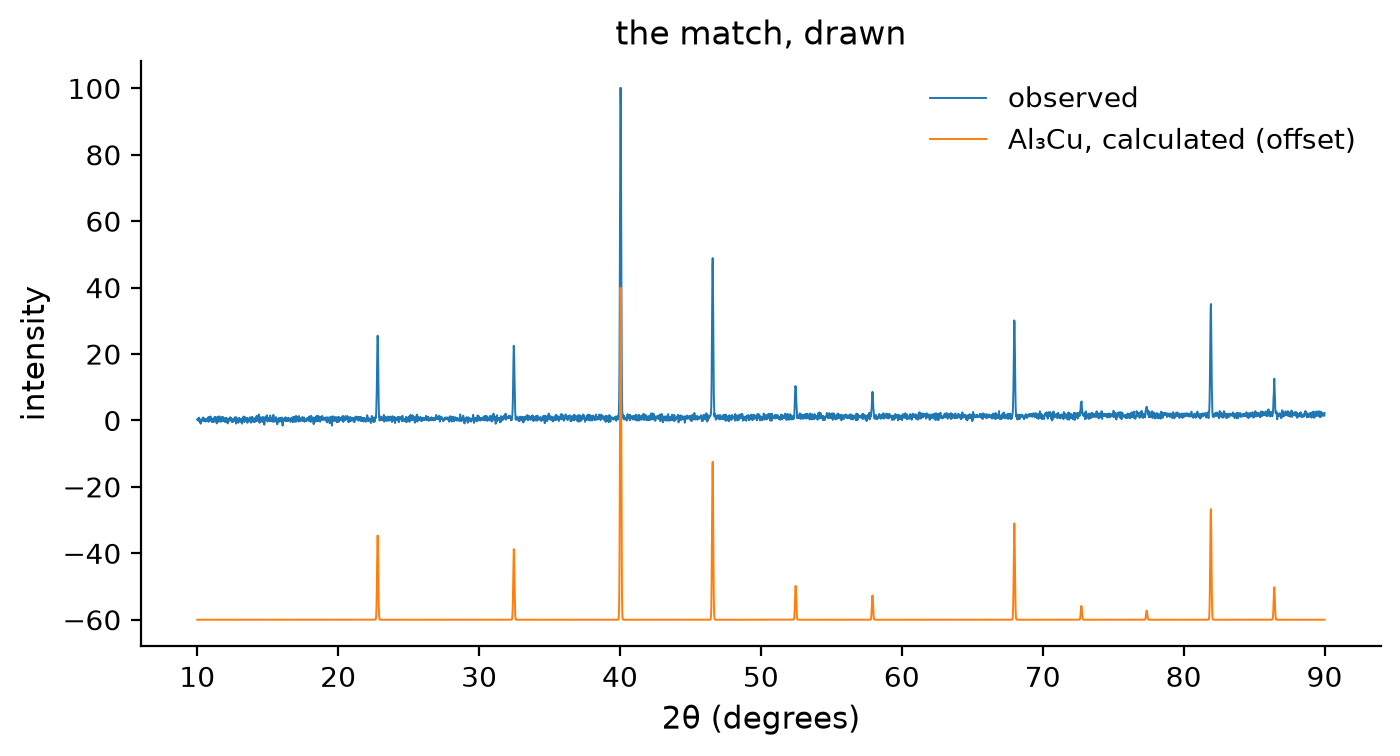

In [30]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(two_theta, observed, linewidth=0.7, label="observed")
ax.plot(two_theta, md.obsm["xrd_calc"][3] - 60, linewidth=0.7,
        label="Al₃Cu, calculated (offset)")
ax.set_xlabel("2θ (degrees)")
ax.set_ylabel("intensity")
ax.set_title("the match, drawn")
ax.legend()

Both patterns are baseline-shifted and unit-normalised before the dot product,
so the score reflects peak positions and relative heights rather than exposure
time — which is why the sloping background above did not move the answer.

In [31]:
md.uns["xrd_match"]["best"], md.uns["xrd_match"]["scored_against"]

('3', "this object's candidates only")

```{warning}
`match_xrd` scores against the candidates in this object and nothing else, and
records that fact in `uns['xrd_match']['scored_against']`. A high score means
"the best of what you gave it", not "identified" — the true phase can be absent
from your library entirely.
```

### Attaching a full measured curve

A measurement usually covers a narrower range than the calculation, at its own
resolution. Simulate that: 20–70° on a coarser step.

In [32]:
instrument_grid = np.arange(20.0, 70.0, 0.05)
patterns = np.vstack([
    np.interp(instrument_grid, two_theta, row) + rng.normal(0, 0.3,
                                                            instrument_grid.size)
    for row in md.obsm["xrd_calc"]])

mv.exp.attach(md, "xrd", patterns, instrument_grid, instrument="Bruker D8")
mv.prop.compare_grids(md, "xrd", "calc", "experiment")

md.obs[["formula", "xrd_cosine_calc_vs_experiment",
        "xrd_overlap_calc_vs_experiment"]].round(3)

,formula,xrd_cosine_calc_vs_experiment,xrd_overlap_calc_vs_experiment
0,Al,0.994,2497.0
1,Cu,0.993,2497.0
2,Ni,0.993,2497.0
3,Al3Cu,0.993,2497.0
4,AlCu3,0.994,2497.0
5,Al3Ni,0.993,2497.0
6,AlNi,0.993,2497.0


Measurements are resampled onto the existing grid, because two curves on
different grids cannot be subtracted. Points outside the measured range become
NaN rather than zero, and the comparison runs over the overlap — `overlap` is
the **number of grid points** both curves cover. 2497 of the calculation's 4000
is the 20–70° the instrument saw, out of the 10–90° that was computed.

```{warning}
Attach a measurement at its own resolution or better. Diffraction peaks are
narrow, and resampling onto a grid coarser than the peak width discards them
permanently — no later interpolation brings them back. There is a test in the
suite pinning this behaviour so nobody "fixes" it.
```

## Reconciling databases

If your candidates came from more than one source, their energies are not
directly comparable. Materials Project, OQMD and Alexandria differ in
pseudopotentials, cutoffs and correction schemes, and the resulting offsets have
compositional structure — which makes them a batch effect.

Simulate one. Take every material **twice**, label one copy `mp` and the other
`oqmd`, and shift the `oqmd` copy by a per-element offset. The overlap matters:
harmonisation is a fit, and a fit needs compositions both databases contain.

In [33]:
both = mv.data.from_structures(mv.structures(md) * 2)
mv.pp.describe(both)
mv.pp.normalize_composition(both)
mv.calc.energy(both, level="emt")

offsets = np.array([{"Al": 0.10, "Ni": -0.06, "Cu": 0.03}[e]
                    for e in both.var_names])
shift = np.asarray(both.layers["fraction"].todense()) @ offsets

both.obs["database"] = ["mp"] * md.n_obs + ["oqmd"] * md.n_obs
both.obs["energy_per_atom_dft"] = (
    both.obs["energy_per_atom_emt"].to_numpy(dtype=float)
    + np.where(both.obs["database"] == "oqmd", shift, 0.0))

both.obs[["formula", "database", "energy_per_atom_dft"]].round(4)

,formula,database,energy_per_atom_dft
0,Al,mp,-0.0016
1,Cu,mp,-0.0050
2,Ni,mp,-0.0076
3,Al3Cu,mp,0.0796
4,AlCu3,mp,0.1093
5,Al3Ni,mp,0.1829
6,AlNi,mp,0.4306
7,Al,oqmd,0.0984
8,Cu,oqmd,0.0250
9,Ni,oqmd,-0.0676


In [34]:
mv.pp.harmonize(both, batch_key="database",
                energy_key="energy_per_atom_dft", reference="mp")

both.uns["harmonize"]["diagnostics"]["oqmd"]

{'n_anchors': 7,
 'n_elements_fitted': 3,
 'rmse_before': 0.06274950199005568,
 'rmse_after': 3.5671969773781297e-17,
 'underdetermined': False}

The fitted offsets should recover the ones put in — 0.10, −0.06 and 0.03:

In [35]:
pd.Series(both.uns["harmonize"]["offsets"]["oqmd"],
          index=both.var_names, name="fitted offset").round(3)

element
Al    0.10
Ni   -0.06
Cu    0.03
Name: fitted offset, dtype: float64

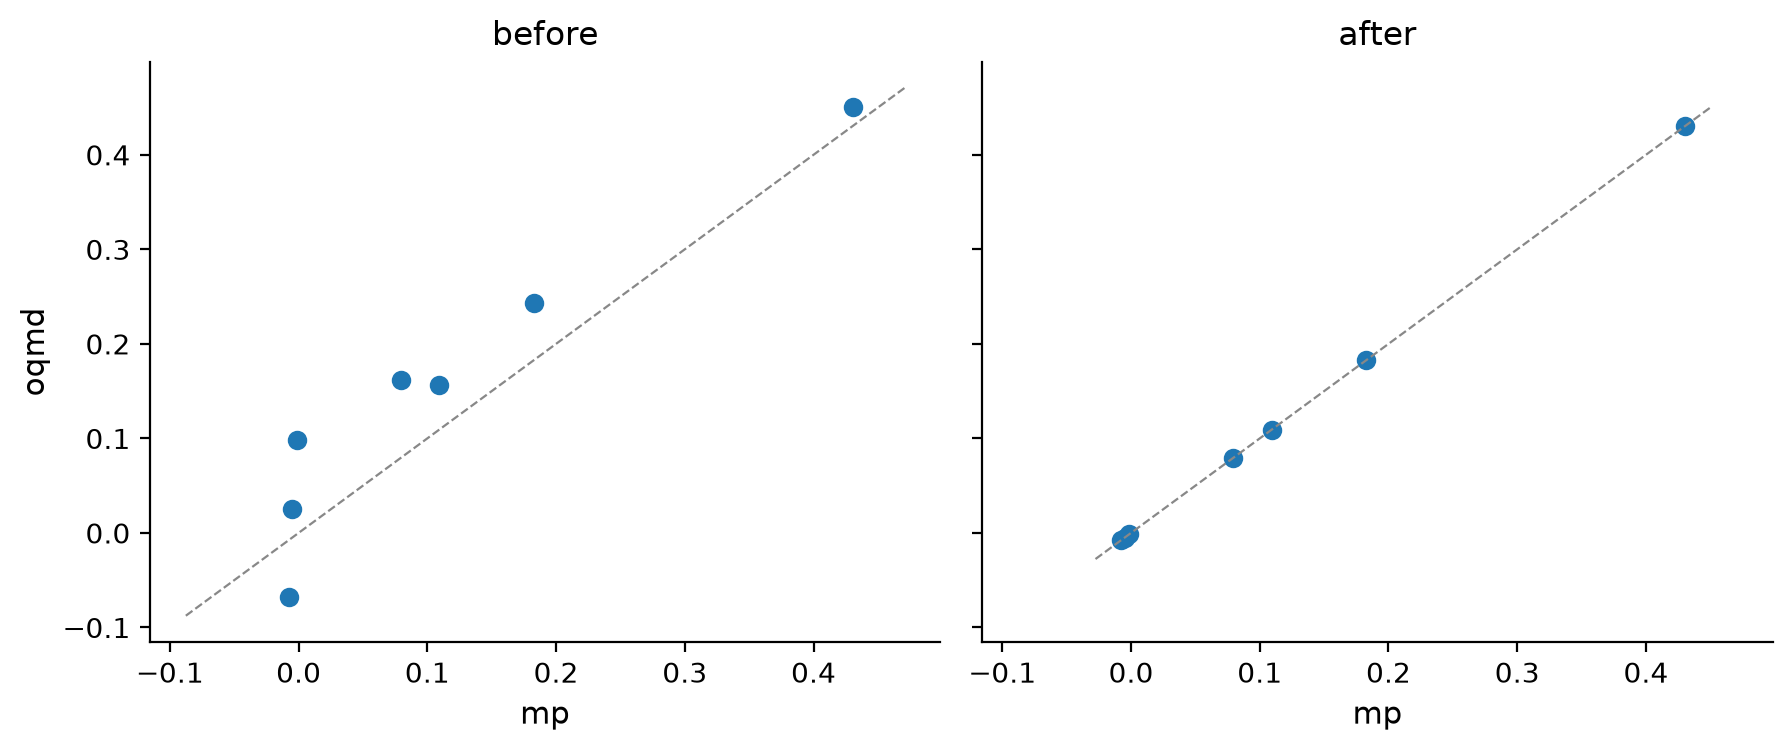

In [36]:
n = md.n_obs
raw = both.obs["energy_per_atom_dft"].to_numpy(dtype=float)
fixed = both.obs["energy_per_atom_dft_harmonized"].to_numpy(dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharex=True, sharey=True)
for ax, values, title in ((axes[0], raw, "before"), (axes[1], fixed, "after")):
    ax.scatter(values[:n], values[n:], s=36)
    lo, hi = values.min() - 0.02, values.max() + 0.02
    ax.plot([lo, hi], [lo, hi], "--", linewidth=0.8, color="#888")
    ax.set_xlabel("mp"); ax.set_title(title)
axes[0].set_ylabel("oqmd")
fig.tight_layout()

Same materials, two databases, plotted against each other. Before, they scatter
off the diagonal in a way that depends on composition; after, they land on it.

The model is the one the field already uses by hand — a per-element reference
offset — fitted by least squares on the compositions two databases share.

```{warning}
It cannot repair a disagreement that is not linear in composition. Two databases
that differ because one relaxed with a different functional will differ
structure by structure, and a compositional offset absorbs only the average of
that. Read `rmse_after`: it is what is left.

`harmonize` also warns and does nothing when the databases share no composition,
because with no anchors there is nothing to fit.
```

## Scoring generated candidates

Substitution within a known structure type is the cheap baseline every
generative model should be measured against — and is what several were found to
be doing implicitly.

In [37]:
generated = mv.gen.substitute(md, {"Al": ["Ga", "In"]}, charge_balanced=False)
mv.pp.describe(generated)

generated.obs[["formula", "parent", "substitution"]].head(8)

,formula,parent,substitution
0,Ga,0,Al->Ga
1,In,0,Al->In
2,Ga3Cu,3,Al->Ga
3,In3Cu,3,Al->In
4,GaCu3,4,Al->Ga
5,InCu3,4,Al->In
6,Ga3Ni,5,Al->Ga
7,In3Ni,5,Al->In


In [38]:
mv.gen.validate(generated, reference=md)

generated.uns["gen_validate"]["rates"]

{'valid': 1.0,
 'unique': 1.0,
 'novel': 1.0,
 'stable': None,
 'sun': None,
 'msun': None}

Validity, uniqueness, novelty and stability use LeMat-GenBench's definitions
rather than a variant, and every parameter is recorded next to the rates:

In [39]:
generated.uns["gen_validate"]["definitions"]

{'min_distance': 0.5,
 'stability_threshold': 0.0,
 'metastability_threshold': 0.1,
 'ltol': 0.2,
 'stol': 0.3,
 'angle_tol': 5.0,
 'source': 'input',
 'level': None,
 'reference': '7 structures',
 'novelty_means': 'absent from the named reference set under StructureMatcher at the stated tolerances',
 'metric_family': 'LeMat-GenBench (arXiv:2512.04562) definitions'}

That matters more than it looks. Until those definitions were pinned, the same
metric name meant different things depending on which reference set, stability
threshold and matching tolerance a paper used — so the numbers were not
comparable even when the names were identical.

```{warning}
Stability is reported as **not assessed** rather than zero when no level is
given or when the hull was built over the dataset's own compositions. A closed
hull cannot say whether anything is stable.
```

In [40]:
generated.uns["gen_validate"]["not_assessed"]

{'stability': 'no level was given, so stability was not assessed'}

Novelty means "absent from the reference set you named", which is a weaker claim
than it sounds. A 2026 stress test found that neither MatterGen nor DiffCSP++
recovered the experimentally observed structures of the newly synthesised
GdNiSn₄ and LuNiSn₄, despite both being built from known motifs — current models
recombine compositions within known structural families. A high novelty rate
measured against a database does not contradict that.

### Where the candidates come from in the first place

`mv.gen.substitute` enumerates the swaps you name. `mv.gen.predict_substitutions`
ranks the swaps you did not think of, from the data-mined ionic substitution
model of Hautier et al. — how often two species replace one another across the
ICSD, rather than whether their radii match.

It needs **oxidation states**, because the model is defined over ionic species:
Fe²⁺ and Fe³⁺ substitute differently and that distinction is the whole point.

In [41]:
cathode = mv.datasets.load("battery_cathodes")[:1].copy()
mv.pp.describe(cathode)
mv.transform.oxidation_states(cathode)

proposed = mv.gen.predict_substitutions(cathode, source="oxidized", n=8)
mv.pp.describe(proposed)
proposed.obs[["parent", "substitution", "substitution_probability",
              "formula"]].round(5)

,parent,substitution,substitution_probability,formula
0,0,P5+->Mn5+,0.00648,LiMnFeO4
1,0,Fe2+->Cd2+,0.00595,LiCdPO4
2,0,Fe2+->V2+,0.00563,LiVPO4
3,0,Fe2+->Ti2+,0.00549,LiTiPO4
4,0,Fe2+->Rh5+,0.00478,LiPRhO4
5,0,O2-->F-,0.00438,LiFePF4
6,0,Fe2+->W5+,0.00432,LiPWO4


From LiFePO₄ it reaches **LiVPO₄** and **LiTiPO₄** — both real olivine
analogues — without being told anything about olivines. The probability is a
prior from what has been made before; it says nothing about whether the
substitution is stable in this structure, which is what the hull is for.

The result is an ordinary materials object, so the whole pipeline runs on it:
`mv.pp.qc`, `mv.calc.relax`, `mv.thermo.hull`.

Doping is the same statistics asked a narrower question:

In [42]:
mv.gen.predict_dopants(cathode, source="oxidized", n=5)
cathode.obs[["name", "n_type_dopant", "n_type_probability",
             "p_type_dopant", "p_type_probability"]].round(4)

,name,n_type_dopant,n_type_probability,p_type_dopant,p_type_probability
0,LiFePO4,F-,0.0669,Na+,0.0492


Fluorine comes out as the n-type choice, which is the doping strategy LiFePO₄ is
actually treated with. n-type versus p-type here is arithmetic on oxidation
states — the dopant carries more charge than the site it replaces, or less — not
a calculation of where the level lands. Whether it is shallow, soluble or
compensated is `mv.thermo.defect_formation`'s question.

A candidate built by substitution keeps the cell it was built from, which can be
several percent from where the new composition wants to sit. Starting a
relaxation there costs steps and can land in a different minimum:

In [43]:
mv.pp.predict_volume(proposed)
proposed.obs[["formula", "volume", "predicted_volume", "volume_scale"]].round(3)

,formula,volume,predicted_volume,volume_scale
0,LiMnFeO4,299.608,449.412,1.500
1,LiCdPO4,299.608,312.912,1.044
2,LiVPO4,299.608,291.048,0.971
3,LiTiPO4,299.608,290.763,0.970
4,LiPRhO4,299.608,292.564,0.976
5,LiFePF4,299.608,330.088,1.102
6,LiPWO4,299.608,292.677,0.977


No calculator involved — the prediction comes from tabulated bond lengths — and
`volume_scale` records how far the cell moved, so a suspicious rescaling is
visible rather than silent.

### The inverse question

`mv.gen.predict_substitutions` starts from a structure and asks what could be
swapped into it. `mv.gen.predict_hosts` starts from a **composition** and asks
which of the structures you already have could hold it — which is the more
useful direction when you know what you want.

In [44]:
hosts = mv.gen.predict_hosts(cathode, ["Na+", "Mn2+", "P5+", "O2-"],
                             source="oxidized")
mv.pp.describe(hosts)
hosts.obs[["parent", "target", "host_probability", "formula"]].round(5)

,parent,target,host_probability,formula
0,0,"Na+, Mn2+, P5+, O2-",0.00277,NaMnPO4


From LiFePO₄ alone it builds **NaMnPO₄** — a real sodium-ion cathode — because
the model has seen Li→Na and Fe→Mn often enough in the ICSD.

The library you pass *is* the search space, so a database export finds far more
than three structures will.

```{note}
The species count has to match. A four-species target only considers
four-species hosts, because the model substitutes one for one and never changes
how many there are. Ask for a two-species target against this library and it
says so rather than returning an empty list — "no host found... it only
considers hosts with 2 distinct species; this library has [4]".
```

```{seealso}
[Models and campaigns](models_and_campaigns.ipynb) covers the other half:
predicting what you have not computed, and choosing what to compute next.
```

## Why a material is piezoelectric, not just how much

`mv.prop.piezoelectric` above took a tensor somebody else computed.
`mv.prop.piezo_from_dfpt` builds it from the three things a DFPT run produces:

$$e = Z^{*} \cdot \mathrm{pinv}(-\Phi) \cdot \Lambda$$

Born effective charges, the inverse force-constant matrix, and the internal
strain tensor. Keeping them apart is what tells you *why* a material responds,
which the finished tensor cannot.

In [45]:
from pymatgen.core import Lattice, Structure

cell = Structure(Lattice.cubic(4.0), ["Ba", "Ti", "O", "O"],
                 [[0, 0, 0], [.5, .5, .5], [.5, .5, 0], [.5, 0, .5]])
candidates = mv.data.from_structures([cell] * 3)
candidates.obs_names = ["baseline", "twice the Born charges", "twice as stiff"]

rng = np.random.RandomState(0)
n = len(cell)
force = rng.randn(n * 3, n * 3)
force = (force + force.T) / 2
fcm = np.reshape(force, (n, 3, n, 3)).swapaxes(1, 2)
bec, ist = rng.randn(n, 3, 3), rng.randn(n, 3, 3, 3)

mv.prop.piezo_from_dfpt(candidates,
                        [bec, 2 * bec, bec], ist, [fcm, fcm, 2 * fcm])
candidates.obs[["piezo_max_dfpt", "piezo_norm_dfpt"]].round(3)

,piezo_max_dfpt,piezo_norm_dfpt
baseline,45.187,116.430
twice the Born charges,90.374,232.860
twice as stiff,22.593,58.215


Doubling the Born charges doubles the response. Doubling the force constants
halves it. Both are exact — they fall straight out of the expression — and
together they are the trade-off that decides real materials: **a soft lattice
with ordinary Born charges beats a stiff one with large charges.**

That is invisible in a single piezoelectric coefficient and obvious here, which
is the reason to compute the tensor from its parts rather than to receive it.

```{note}
All three are arguments, one set per row or one shared: Born charges
`(n_sites, 3, 3)`, internal strain `(n_sites, 3, 3, 3)`, force constants
`(n_sites, n_sites, 3, 3)`. They come from density functional perturbation
theory, which matverse does not run.

The pseudo-inverse drops the three translational modes — their eigenvalues are
zero and their inverse is not — and `rcond` sets where that cut falls.
```

## The polarization that is not a number

Polarization is only defined **modulo a quantum** — one lattice vector of charge
per cell. A Berry-phase calculation does not return the polarization; it returns
one representative of an infinite set. Along a switching path the values come
back scattered across branches, and subtracting the first from the last gives an
answer wrong by an arbitrary multiple of the quantum.

This is the single most common way a computed ferroelectric polarization gets
reported wrongly, and it is invisible: the number looks perfectly reasonable.

Here is a path whose true polarization rises smoothly from 0 to 30 μC/cm², with
a random multiple of the quantum added to each point — which is exactly what a
real calculation hands you:

In [46]:
from pymatgen.core import Lattice, Structure

a, n = 4.0, 7
path = mv.data.from_structures([
    Structure(Lattice.cubic(a), ["Ba", "Ti", "O", "O", "O"],
              [[0, 0, 0], [.5, .5, .5 + x], [.5, .5, 0], [.5, 0, .5],
               [0, .5, .5]])
    for x in np.linspace(0.0, 0.04, n)])

true_path = np.linspace(0.0, 30.0, n)
quantum = 100.136
scattered = true_path + quantum * np.random.RandomState(0).randint(-2, 3, n)

p_elec = np.zeros((n, 3))
p_elec[:, 2] = scattered * a ** 3 / 1602.1766208

print("what the calculation returns:", scattered.round(1))

what the calculation returns: [ 200.3 -195.3  110.1  115.1  120.1  -75.1  130.1]


Nothing about that sequence looks like a smooth ferroelectric switching path.
Subtract the ends and you get 130.1 − 200.3 = −70 μC/cm², which is not the
answer.

`mv.prop.polarization` puts every point back on one branch by following the
smallest step from its predecessor:

In [47]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")     # the path is coarse; see the note
    mv.prop.polarization(path, p_elec, np.zeros((n, 3)))

print("reconstructed:", np.abs(path.obs["polarization_c"].to_numpy()).round(2))
print("true path    :", true_path.round(2))
path.uns["polarization"]["polarization"]["spontaneous_norm"]

reconstructed: [ 0.  5. 10. 15. 20. 25. 30.]
true path    : [ 0.  5. 10. 15. 20. 25. 30.]


30.000038410529346

The smooth path, recovered exactly, and a spontaneous polarization of
30 μC/cm² instead of −70.

```{warning}
`uns['polarization'][...]['fraction_of_quantum']` is worth reading every time.
If the spontaneous polarization is a sizeable fraction of the quantum, then
consecutive images moved far enough that "nearest branch" is a **guess** rather
than a reading, and matverse warns — as it does above, where 30 against a
quantum of 100 is 0.3. The fix is more images along the path, not a better
algorithm.

**The rows are a path, in order**, from the centrosymmetric reference to the
polar structure. This is the one function here that reads the dataset as a
sequence rather than as a set, so row order is part of the input. The
Berry-phase terms themselves are arguments, as VASP reports them.
```

## Corrections of your own

`mv.thermo.corrections` applies the Materials Project's. Those are calibrated to
PBE+U at MP's cutoffs and pseudopotentials, and they **do not transfer** — not to
r2SCAN, not to a different pseudopotential set, not to a machine-learned
potential. The moment you leave MP's settings you need your own, and deriving
them is a regression of measured against computed formation energies.

Here is a set of oxides where a −0.45 eV per oxygen error has been put in
deliberately, so the fit has a known right answer:

In [48]:
from pymatgen.core import Composition, Lattice, Structure

def stand_in(formula):
    comp = Composition(formula)
    syms = [str(e) for e in comp.elements for _ in range(int(comp[e]))]
    return Structure(Lattice.cubic(10.0), syms,
                     [[i / len(syms), 0, 0] for i in range(len(syms))])

oxides = [("Fe2O3", 3, 2), ("TiO2", 2, 1), ("MgO", 1, 1),
          ("Al2O3", 3, 2), ("ZnO", 1, 1), ("CaO", 1, 1)]
elements = ["Fe", "Ti", "Mg", "Al", "Zn", "Ca", "O2"]
names = [f for f, _, _ in oxides] + elements

calib = mv.data.from_structures([stand_in(n) for n in names])
calib.obs_names = names
calib.obs["energy_pbe"] = ([-3.0 * o - 2.0 * m for _, o, m in oxides]
                           + [0.0] * len(elements))
calib.obs["e_above_hull_pbe"] = [0.0] * len(names)
# measured = computed, minus 0.45 eV for every oxygen
calib.obs["dHf"] = ([-3.0 * o - 2.0 * m - 0.45 * o for _, o, m in oxides]
                    + [float("nan")] * len(elements))

mv.thermo.fit_corrections(calib, "dHf", level="pbe",
                          max_error=5.0, allow_unstable=True)
calib.uns["fitted_corrections"]["pbe"]["corrections"]

{'oxide': [-0.45, 0.002], 'ozonide': [0.0, 0.0]}

**−0.45 eV per oxygen, recovered to four decimals**, with an error bar beside
it. The corrected energies are deposited too, so Fe₂O₃ moves by three times the
correction and the elements do not move at all:

In [49]:
calib.obs.loc[["Fe2O3", "MgO", "Fe"],
              ["energy_pbe", "correction_pbe", "energy_corrected_pbe"]]

,energy_pbe,correction_pbe,energy_corrected_pbe
Fe2O3,-13.0,-1.35,-14.35
MgO,-5.0,-0.45,-5.45
Fe,0.0,0.00,0.00


```{warning}
**The measured column is a formation energy per formula unit**, not per atom.
Getting that wrong rescales every correction by the formula size and fails
silently — the fit still converges and still reports a small error bar. This
convention was read out of pymatgen's source rather than guessed; two earlier
attempts at inferring it from the outputs gave factors of 0.26 and 8 that
nothing explained.

The elements have to be rows of the dataset at the same level of theory,
because that is what a formation energy is measured against. matverse refuses
rather than assuming, since an elemental energy from a different functional
would shift every correction by an unknown constant.

And six compounds is six compounds. MP2020 used thousands; the error bar
returned here is doing real work.
```

## A hull the laboratory built

Everything above compares a calculation with a measurement one row at a time.
Stability is not a row-at-a-time quantity — it is a property of a whole chemical
system — so comparing *it* means building the convex hull twice, once from
computed energies and once from measured formation enthalpies.

`mv.exp.formation_hull` does the second. The unit is a required argument, and
that is the whole point:

In [50]:
from pymatgen.core import Composition, Lattice, Structure

def cell(formula):
    comp = Composition(formula)
    syms = [str(e) for e in comp.elements for _ in range(int(comp[e]))]
    return Structure(Lattice.cubic(10.0), syms,
                     [[i / len(syms), 0, 0] for i in range(len(syms))])

# NIST-JANAF standard formation enthalpies at 298 K, in kJ/mol
janaf = {"Fe2O3": -824.2, "Fe3O4": -1118.4, "FeO": -272.0, "Fe": 0.0}

oxides = mv.data.from_structures([cell(f) for f in janaf])
oxides.obs_names = list(janaf)
mv.exp.measure(oxides, "dHf", list(janaf.values()), level="janaf",
               instrument="NIST-JANAF tables")
mv.exp.formation_hull(oxides, "dHf_janaf", unit="kJ/mol", level="janaf")

oxides.obs[["dHf_janaf", "formation_energy_janaf", "e_above_hull_janaf",
            "is_stable_janaf"]].round(4)

,dHf_janaf,formation_energy_janaf,e_above_hull_janaf,is_stable_janaf
Fe2O3,-824.2,-1.7084,0.0000,True
Fe3O4,-1118.4,-1.6559,0.0000,True
FeO,-272.0,-1.4095,0.0394,False
Fe,0.0,0.0000,0.0000,True


Hematite and magnetite sit on the hull. **Wüstite sits 0.039 eV/atom above it**
— and that is not a defect of the method, it is metallurgy: FeO is metastable at
room temperature and disproportionates into iron and magnetite below about
570 °C. A hull built from measured enthalpies that put all three phases on it
would be the suspicious result.

Two things had to go right to get there, and both are places pymatgen's
`ExpEntry` goes wrong.

The first is **units**. A table quotes kJ per mole of formula unit; a hull is in
eV per atom. Between them sit a factor of 96.485 and the number of atoms in the
formula. `ExpEntry` hands the table's number straight to `PDEntry` as though it
were already eV, and `ThermoData` carries no unit for it to check against — so
the hull comes out wrong by two orders of magnitude, and still ranks, still
plots, still returns an `e_above_hull`.

The second is the **oxygen corner**. A formation enthalpy is measured against
the elements, so an Fe–O hull needs an O₂ reference at zero, and nobody has a
row for oxygen gas. `mv.exp.formation_hull` adds the elemental references
itself; `ExpEntry` cannot hold one at all, because it rejects any phase marked
gas or liquid.

In [51]:
oxides.uns["experimental_hull"]["janaf"]["stable"]

['Fe', 'Fe2O3', 'Fe3O4', 'O2']

Now the comparison this was for. Run `mv.thermo.hull` at a computed level on the
same object and the two `e_above_hull` columns sit side by side on the same
rows, which is the only honest way to ask whether a functional is *right* about
stability rather than merely self-consistent.

## A hull is not a phase diagram

`mv.thermo.hull` computes a convex hull **at 0 K** from energies this library
produced. That extends to compositions nobody has ever assessed, and it says
nothing about what happens at 800 K, about liquids, or about solution phases.

`mv.thermo.calphad` reads the other kind of answer: parameters fitted to
*measured* phase boundaries, giving multicomponent equilibrium at temperature.
Neither supersedes the other — the hull reaches further, CALPHAD is right about
where it reaches.

In [52]:
try:
    import pathlib
    import pycalphad

    tdb = next(pathlib.Path(pycalphad.__file__).parent.rglob("pbsn.tdb"))
    alloys = mv.data.from_compositions(
        ["Pb0.261Sn0.739", "Pb0.9Sn0.1", "Pb0.1Sn0.9"])
    alloys.obs_names = ["eutectic", "Pb-rich", "Sn-rich"]

    for temperature in (450.0, 455.0):
        out = alloys.copy()
        mv.thermo.calphad(out, str(tdb), temperature=temperature)
        print(f"--- {temperature:.0f} K ---")
        print(out.obs[["calphad_phases", "calphad_major_fraction"]]
              .round(3).to_string())
except ImportError:
    print("needs pycalphad; pip install matverse[calphad]")

--- 450 K ---
           calphad_phases  calphad_major_fraction
eutectic  FCC_A1 + BCT_A5                   0.672
Pb-rich            FCC_A1                   1.000
Sn-rich   FCC_A1 + BCT_A5                   0.894
--- 455 K ---
           calphad_phases  calphad_major_fraction
eutectic           LIQUID                   1.000
Pb-rich            FCC_A1                   1.000
Sn-rich   LIQUID + BCT_A5                   0.678


The Pb-Sn eutectic is measured at **456 K**, and those two temperatures
straddle it: at 450 K the eutectic composition is two solid phases, at 455 K it
is a single liquid. The off-eutectic compositions melt over a range instead —
`LIQUID + BCT_A5` is a partial melt, which is what an alloy away from the
eutectic does.

```{warning}
**The database is the whole calculation.** matverse ships none; assessed
databases are years of work and mostly licensed, so you supply one and
`uns['calphad']` records which. Two assessments of the same system will
disagree, and that spread is the honest error bar on any number here — not the
precision of the numbers themselves.

A material containing an element the database does not assess is **skipped and
counted**, never projected onto the elements that remain. Dropping the copper
from PbSnCu and renormalising would answer a question about a different alloy.
```